In [1]:
import pandas as pd
import os
from pathlib import Path
import numpy as np
images_dir = '/backup/lucas/datasets/origa/ORIGA/Images'
csv_path = '/backup/lucas/datasets/origa/ORIGA/OrigaList.csv' 

# Ler o CSV
df = pd.read_csv(csv_path)

# Criar uma função para obter o path completo da imagem
def get_image_path(filename):
    return os.path.join(images_dir, filename)

# Adicionar a coluna com o path completo
df['ImagePath'] = df['Filename'].apply(get_image_path)

# Verificar quais imagens existem de fato no diretório
df['ImageExists'] = df['ImagePath'].apply(os.path.exists)

df_valid = df[df['ImageExists']].copy()

# Visualizar o resultado
print(f"Total de registros no CSV: {len(df)}")
print(f"Imagens encontradas: {df['ImageExists'].sum()}")
print(f"\nPrimeiras linhas do DataFrame:")
print(df_valid.head())

print(f"\nDistribuição de Glaucoma:")
print(df_valid['Glaucoma'].value_counts())

df_valid.to_csv('origa_processed.csv', index=False)

Total de registros no CSV: 650
Imagens encontradas: 650

Primeiras linhas do DataFrame:
  Eye Filename  ExpCDR Set  Glaucoma  \
0  OD  001.jpg  0.7097   A         0   
1  OS  002.jpg  0.6953   A         0   
2  OS  003.jpg  0.9629   A         0   
3  OD  004.jpg  0.7246   A         0   
4  OS  005.jpg  0.6138   A         0   

                                           ImagePath  ImageExists  
0  /backup/lucas/datasets/origa/ORIGA/Images/001.jpg         True  
1  /backup/lucas/datasets/origa/ORIGA/Images/002.jpg         True  
2  /backup/lucas/datasets/origa/ORIGA/Images/003.jpg         True  
3  /backup/lucas/datasets/origa/ORIGA/Images/004.jpg         True  
4  /backup/lucas/datasets/origa/ORIGA/Images/005.jpg         True  

Distribuição de Glaucoma:
Glaucoma
0    482
1    168
Name: count, dtype: int64


In [2]:
df_valid

,Eye,Filename,ExpCDR,Set,Glaucoma,ImagePath,ImageExists
0,OD,001.jpg,0.7097,A,0,/backup/lucas/datasets/origa/ORIGA/Images/001.jpg,True
1,OS,002.jpg,0.6953,A,0,/backup/lucas/datasets/origa/ORIGA/Images/002.jpg,True
2,OS,003.jpg,0.9629,A,0,/backup/lucas/datasets/origa/ORIGA/Images/003.jpg,True
3,OD,004.jpg,0.7246,A,0,/backup/lucas/datasets/origa/ORIGA/Images/004.jpg,True
4,OS,005.jpg,0.6138,A,0,/backup/lucas/datasets/origa/ORIGA/Images/005.jpg,True
...,...,...,...,...,...,...,...
645,OD,646.jpg,0.6560,A,1,/backup/lucas/datasets/origa/ORIGA/Images/646.jpg,True
646,OD,647.jpg,0.7365,A,1,/backup/lucas/datasets/origa/ORIGA/Images/647.jpg,True
647,OS,648.jpg,0.5101,A,1,/backup/lucas/datasets/origa/ORIGA/Images/648.jpg,True
648,OD,649.jpg,0.5227,B,0,/backup/lucas/datasets/origa/ORIGA/Images/649.jpg,True


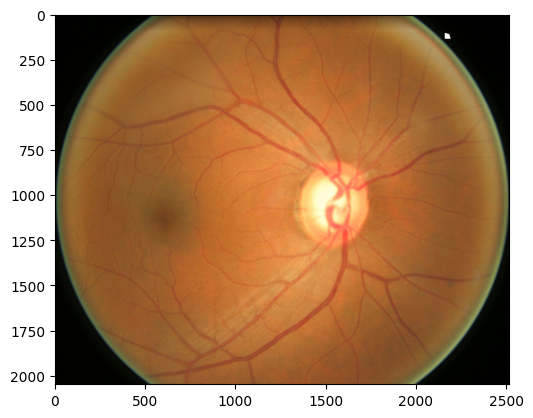

In [3]:
### ler uma iamgem e plotar usando matplotlib 
import matplotlib.pyplot as plt
image_path = df_valid.iloc[0]['ImagePath']
image = plt.imread(image_path)
plt.imshow(image)
plt.axis('on')
plt.show()

In [2]:
from data_factory.data_factory import DataFactory


factory = DataFactory(
    img_path='/backup/lucas/datasets/origa/ORIGA/Images',
    metadata_path='/backup/lucas/datasets/origa/ORIGA/OrigaList.csv'
)

df = factory.load_data(verbose=True)

Número de registros no CSV: 650
Número de arquivos válidos após filtragem: 650
Distribuição de diagnósticos: {0: 482, 1: 168}


In [34]:
df

,patient_id,filepath,binary_label,diagnosis_code
0,001,/backup/lucas/datasets/origa/ORIGA/Images/001.jpg,0,0
1,002,/backup/lucas/datasets/origa/ORIGA/Images/002.jpg,0,0
2,003,/backup/lucas/datasets/origa/ORIGA/Images/003.jpg,0,0
3,004,/backup/lucas/datasets/origa/ORIGA/Images/004.jpg,0,0
4,005,/backup/lucas/datasets/origa/ORIGA/Images/005.jpg,0,0
...,...,...,...,...
645,646,/backup/lucas/datasets/origa/ORIGA/Images/646.jpg,1,1
646,647,/backup/lucas/datasets/origa/ORIGA/Images/647.jpg,1,1
647,648,/backup/lucas/datasets/origa/ORIGA/Images/648.jpg,1,1
648,649,/backup/lucas/datasets/origa/ORIGA/Images/649.jpg,0,0


In [ ]:
from torchvision import transforms
import cv2
from PIL import Image

    
def get_transforms(img_size=256):
    
    # Pipeline de TREINO
    train_transforms = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(degrees=360), 
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    val_transforms = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    return train_transforms, val_transforms

In [4]:
from data_factory.RetinaDataset import RetinaDataset

train_transforms, val_transforms = get_transforms(img_size=256)

source_dataset = RetinaDataset(dataframe=df, transform=train_transforms, domain_label=0)
print(f"Tamanho Dataset Source (ORIGA)", len(source_dataset))

Tamanho Dataset Source (ORIGA) 650


In [5]:
ROP_factory = DataFactory(
    img_path='/backup/pedro_fonseca/PATIENT_ROP/DATASET/images_stack/images_stack',
    metadata_path='DATASET/infant_retinal_database_info.csv'
)

ROP_df = ROP_factory.load_data_ROP(verbose=True)

Número de arquivos de imagem encontrados: 6004
Número de arquivos válidos após filtragem: 6004


In [37]:
ROP_df

,patient_id,filepath,binary_label,diagnosis_code
0,064,/backup/pedro_fonseca/PATIENT_ROP/DATASET/imag...,0,0
1,110,/backup/pedro_fonseca/PATIENT_ROP/DATASET/imag...,0,0
2,170,/backup/pedro_fonseca/PATIENT_ROP/DATASET/imag...,1,11
3,152,/backup/pedro_fonseca/PATIENT_ROP/DATASET/imag...,0,0
4,120,/backup/pedro_fonseca/PATIENT_ROP/DATASET/imag...,0,0
...,...,...,...,...
5999,062,/backup/pedro_fonseca/PATIENT_ROP/DATASET/imag...,0,0
6000,096,/backup/pedro_fonseca/PATIENT_ROP/DATASET/imag...,0,0
6001,107,/backup/pedro_fonseca/PATIENT_ROP/DATASET/imag...,0,0
6002,007,/backup/pedro_fonseca/PATIENT_ROP/DATASET/imag...,1,11


In [6]:
target_dataset = RetinaDataset(dataframe=ROP_df, transform=train_transforms, domain_label=1)

In [12]:
from torch.utils.data import DataLoader
source_dataloader = DataLoader(source_dataset, batch_size=32, shuffle=True, drop_last=True)
target_dataloader = DataLoader(target_dataset, batch_size=32, shuffle=True, drop_last=True)

def infinite_iterable(loader):
    '''
        Necessário caso haja datasets de tamanhos diferentes, isso pq vamos iterar simultaneamente sobre os dois dataloaders
    '''
    while True:
        for batch in loader:
            yield batch

source_iter = infinite_iterable(source_dataloader)
target_iter = infinite_iterable(target_dataloader)

#Definindo a quantidade de steps com base em qual dataset é menor
min_dataset_size = min(len(source_dataset), len(target_dataset))
num_steps = min_dataset_size // 32  # considerando batch size de 32


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

class GradientReversalFn(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        
        output = grad_output.neg() * ctx.alpha
        return output, None

def grad_reverse(x, alpha=1.0):
    return GradientReversalFn.apply(x, alpha)

In [ ]:
class EfficientNetDANN(nn.Module):
    def __init__(self, num_classes=2, pre_trained=True):
        super(EfficientNetDANN, self).__init__()
        
        
        weights = models.EfficientNet_B0_Weights.DEFAULT if pre_trained else None
        self.backbone = models.efficientnet_b0(weights=weights)
        
        n_features = self.backbone.classifier[1].in_features
        
        self.backbone.classifier = nn.Identity()
        
        
        self.class_classifier = nn.Sequential(
            nn.Dropout(p=0.2), # Dropout padrão da EffNet
            nn.Linear(n_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(512, num_classes) # Saída: logits da doença
        )

        
        self.domain_classifier = nn.Sequential(
            nn.Linear(n_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 1) 
        )

    def forward(self, x, alpha=1.0):
        features = self.backbone.features(x)
        features = self.backbone.avgpool(features)
        features = torch.flatten(features, 1)


        class_output = self.class_classifier(features)

        # Inversão do Gradiente
        reverse_features = grad_reverse(features, alpha)
        domain_output = self.domain_classifier(reverse_features)

        return class_output, domain_output

In [ ]:
def get_alpha(current_step, total_steps):
    """
    Calcula o alpha progressivo (schedule) sugerido no paper original do DANN.
    Vai de 0.0 a 1.0 seguindo uma curva sigmoide.
    """
    p = float(current_step) / total_steps
    return 2. / (1. + np.exp(-10 * p)) - 1

def mixup_data(x1, x2, alpha=1.0):
    """
    Realiza o MixUp entre dois batches de imagens.
    Retorna a imagem misturada e o lambda usado.
    """
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x1.size(0)
    
    mixed_x = lam * x1 + (1 - lam) * x2
    return mixed_x, lam

In [ ]:
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import Subset
import copy

# Função para resetar o modelo a cada fold
def get_new_model(device):
    model = EfficientNetDANN(num_classes=2, pre_trained=True)
    return model.to(device)

In [11]:
#Buscando pela coluna 'binary_label'
target_labels = target_dataset.dataframe.iloc[:, 2].values
target_labels

array([0, 0, 1, ..., 0, 1, 0])

In [ ]:
from torch import optim
import matplotlib.pyplot as plt

def train_dann_kfold(source_dataset, target_dataset, k_folds=5, num_epochs=10, device=torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')):
    print("DEVICE:", device)
    target_labels = target_dataset.dataframe.iloc[:, target_dataset.label_col_idx].values
    skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)
    indices = np.arange(len(target_dataset))
    
    fold_results = [] 

    for fold, (train_idx, val_idx) in enumerate(skf.split(indices, target_labels)):
        print(f"\n{'='*40}")
        print(f"INICIANDO FOLD {fold+1}/{k_folds}")
        print(f"{'='*40}")
        
        # Resetar tudo
        model = get_new_model(device)
        optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
        
        source_loader = DataLoader(source_dataset, batch_size=32, shuffle=True, drop_last=True)
        target_train_subset = Subset(target_dataset, train_idx)
        target_loader = DataLoader(target_train_subset, batch_size=32, shuffle=True, drop_last=True)
        
        iter_source = infinite_iterable(source_loader)
        iter_target = infinite_iterable(target_loader)
        
        steps_per_epoch = min(len(source_loader), len(target_loader))
        total_steps = num_epochs * steps_per_epoch
        
        criterion_class = nn.CrossEntropyLoss()
        criterion_domain = nn.BCEWithLogitsLoss()

        history = {
            'class_loss': [],
            'domain_loss': [],
            'total_loss': []
        }

        global_step = 0
        model.train()
        
        for epoch in range(num_epochs):
            running_class_loss = 0.0
            running_domain_loss = 0.0
            running_total_loss = 0.0
            
            for i in range(steps_per_epoch):
                global_step += 1
                alpha = get_alpha(global_step, total_steps)
                
                
                img_s, label_s, _ = next(iter_source)
                img_t, _, _ = next(iter_target)
                
                img_s, img_t = img_s.to(device), img_t.to(device)
                label_s = label_s.to(device)
                
                domain_y_s = torch.zeros(img_s.size(0), 1).to(device)
                domain_y_t = torch.ones(img_t.size(0), 1).to(device)
                
                optimizer.zero_grad()
                
                class_preds_s, _ = model(img_s, alpha=alpha)
                loss_class = criterion_class(class_preds_s, label_s)
                
                # 2. Domínio (Source + Target)
                _, domain_preds_s = model(img_s, alpha=alpha)
                loss_dom_s = criterion_domain(domain_preds_s, domain_y_s)
                
                _, domain_preds_t = model(img_t, alpha=alpha)
                loss_dom_t = criterion_domain(domain_preds_t, domain_y_t)
                
                # mixup inter-domínio
                img_mix, lam = mixup_data(img_s, img_t, alpha=1.0)
                img_mix = img_mix.to(device)
                mixed_domain_label = (1 - lam) * torch.ones(img_s.size(0), 1).to(device)
                
                _, domain_preds_mix = model(img_mix, alpha=alpha)
                loss_dom_mix = criterion_domain(domain_preds_mix, mixed_domain_label)
                
                # --- Loss Final ---
                loss_domain_combined = (loss_dom_s + loss_dom_t + loss_dom_mix)
                loss_total = loss_class + loss_domain_combined * 0.5
                
                loss_total.backward()
                optimizer.step()
                running_class_loss += loss_class.item()
                running_domain_loss += loss_domain_combined.item()
                running_total_loss += loss_total.item()

            avg_class = running_class_loss / steps_per_epoch
            avg_domain = running_domain_loss / steps_per_epoch
            avg_total = running_total_loss / steps_per_epoch
            
            history['class_loss'].append(avg_class)
            history['domain_loss'].append(avg_domain)
            history['total_loss'].append(avg_total)

            print(f"Epoch [{epoch+1}/{num_epochs}] "
                  f"Class Loss: {avg_class:.4f} | "
                  f"Dom Loss: {avg_domain:.4f} | "
                  f"Total: {avg_total:.4f}")

        save_path = f"dann_model_fold_{fold+1}.pth"
        torch.save(model.state_dict(), save_path)
        
    
        fold_results.append({
            'fold': fold + 1,
            'model_path': save_path,
            'history': history
        })

    return fold_results

efficient_model = EfficientNetDANN(num_classes=2, pre_trained=True)
efficient_model = efficient_model.to('cuda')
results = train_dann_kfold(source_dataset, target_dataset, k_folds=5, num_epochs=30)

DEVICE: cuda:0

INICIANDO FOLD 1/5
Epoch [1/30] Class Loss: 0.6411 | Dom Loss: 2.2362 | Total: 1.7592
Epoch [2/30] Class Loss: 0.5645 | Dom Loss: 2.1685 | Total: 1.6488
Epoch [3/30] Class Loss: 0.5375 | Dom Loss: 2.1497 | Total: 1.6123
Epoch [4/30] Class Loss: 0.5001 | Dom Loss: 2.1042 | Total: 1.5522
Epoch [5/30] Class Loss: 0.4928 | Dom Loss: 2.1135 | Total: 1.5496
Epoch [6/30] Class Loss: 0.4859 | Dom Loss: 2.0976 | Total: 1.5347
Epoch [7/30] Class Loss: 0.4803 | Dom Loss: 2.1159 | Total: 1.5382
Epoch [8/30] Class Loss: 0.4751 | Dom Loss: 2.1154 | Total: 1.5328
Epoch [9/30] Class Loss: 0.4709 | Dom Loss: 2.1022 | Total: 1.5220
Epoch [10/30] Class Loss: 0.4541 | Dom Loss: 2.0965 | Total: 1.5024
Epoch [11/30] Class Loss: 0.4502 | Dom Loss: 2.0920 | Total: 1.4962
Epoch [12/30] Class Loss: 0.4344 | Dom Loss: 2.0933 | Total: 1.4811


# Primeiro estudo


In [6]:
from data_factory.ROP_dataset import ROPDataset


rop_dataset = ROPDataset(df, is_train=False, apply_clahe=True)

In [7]:
X_train, y_train, train_indx, patient_ids_train, gkf, test_dataset = factory.prepare_data_for_cross_validation_3(rop_dataset, num_splits=5)

=== Estatísticas após filtragem ===
Número total de pacientes: 650
Número total de imagens: 650
Pacientes por tipo:
patient_type
normal_only    482
rop_only       168
Name: count, dtype: int64

=== Split treino/teste ===
Pacientes treino: 520 | Pacientes teste: 130
Imagens treino: 520 | Imagens teste: 130
Distribuição de classes (treino): Counter({0: 386, 1: 134})
Distribuição de classes (teste): Counter({0: 96, 1: 34})


In [13]:
print("\n=== Distribuição de classes em cada fold (GroupKFold) ===")
for fold, (train_idx_fold, val_idx_fold) in enumerate(gkf.split(X_train, y_train, groups=patient_ids_train)):
    y_train_fold = np.array(y_train)[train_idx_fold]
    y_val_fold = np.array(y_train)[val_idx_fold]

    train_counts = pd.Series(y_train_fold).value_counts().sort_index()
    val_counts = pd.Series(y_val_fold).value_counts().sort_index()

    train_perc = (train_counts / len(y_train_fold) * 100).round(2)
    val_perc = (val_counts / len(y_val_fold) * 100).round(2)

    print(f"\n*Fold {fold+1}")
    print("Treino:")
    for cls in train_counts.index:
        print(f"  Classe {cls}: {train_counts[cls]} amostras ({train_perc[cls]}%)")
    print("Validação:")
    for cls in val_counts.index:
        print(f"  Classe {cls}: {val_counts[cls]} amostras ({val_perc[cls]}%)")
    print("--------------------------------------------------")


=== Distribuição de classes em cada fold (GroupKFold) ===

*Fold 1
Treino:
  Classe 0: 302 amostras (72.6%)
  Classe 1: 114 amostras (27.4%)
Validação:
  Classe 0: 84 amostras (80.77%)
  Classe 1: 20 amostras (19.23%)
--------------------------------------------------

*Fold 2
Treino:
  Classe 0: 306 amostras (73.56%)
  Classe 1: 110 amostras (26.44%)
Validação:
  Classe 0: 80 amostras (76.92%)
  Classe 1: 24 amostras (23.08%)
--------------------------------------------------

*Fold 3
Treino:
  Classe 0: 314 amostras (75.48%)
  Classe 1: 102 amostras (24.52%)
Validação:
  Classe 0: 72 amostras (69.23%)
  Classe 1: 32 amostras (30.77%)
--------------------------------------------------

*Fold 4
Treino:
  Classe 0: 310 amostras (74.52%)
  Classe 1: 106 amostras (25.48%)
Validação:
  Classe 0: 76 amostras (73.08%)
  Classe 1: 28 amostras (26.92%)
--------------------------------------------------

*Fold 5
Treino:
  Classe 0: 312 amostras (75.0%)
  Classe 1: 104 amostras (25.0%)
Validaçã

In [9]:
## Treino
from train_and_val_worker_ORIGA import TrainAndEvalWorkerOriga
import torch

print("Iniciando treino com validação cruzada...")
trainer = TrainAndEvalWorkerOriga(config=None)
# fold_results = trainer.train(X_train=X_train, 
#                              y_train=y_train, 
#                              patient_ids_train=patient_ids_train, 
#                              train_index=train_indx, 
#                              gkf=gkf,
#                              rop_dataset=rop_dataset)




/home/pedro_fsc_gpu1/.conda/envs/den_reform/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Iniciando treino com validação cruzada...
Configuração vazia fornecida. Utilizando valores padrão.


In [16]:
print("\n=== Resultados por fold ===")
for i, result in enumerate(fold_results):
    print(f"Fold {i+1}: Best Val AUC = {result['best_val_auc']:.4f}, Best Threshold = {result['best_threshold']:.4f}")


=== Resultados por fold ===
Fold 1: Best Val AUC = 0.7804, Best Threshold = 0.2812
Fold 2: Best Val AUC = 0.8906, Best Threshold = 0.2345
Fold 3: Best Val AUC = 0.7969, Best Threshold = 0.3710
Fold 4: Best Val AUC = 0.8280, Best Threshold = 0.0993
Fold 5: Best Val AUC = 0.7428, Best Threshold = 0.3619


In [10]:
trainer.evaluate(test_dataset=test_dataset, model_path='saved_models/efficient_ORIGA/best_model.pth')

Modelo carregado de: saved_models/efficient_ORIGA/best_model.pth
Avaliando modelo no conjunto de teste...


Using threshold = 0.5000 for final predictions

Resultados da Avaliação no Conjunto de Teste
Test Loss: 0.3317
Accuracy: 66.15%
Precision: 0.3810
Recall: 0.4706
F1-Score: 0.4211
AUC-ROC: 0.6486

Confusion Matrix:
[[70 26]
 [18 16]]


{'test_loss': 0.33174172131454244,
 'accuracy': 0.6615384615384615,
 'precision': 0.38095238095238093,
 'recall': 0.47058823529411764,
 'f1_score': 0.42105263157894735,
 'auc_roc': np.float64(0.6485906862745098)}